In [1]:
# Ячейка 1 - Установка и импорт
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report
import pickle

# Устанавливаем tensorflow
import subprocess
subprocess.run(['pip', 'install', 'tensorflow', '--quiet'])

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

print(f"TensorFlow версия: {tf.__version__}")
print("Всё готово!")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


TensorFlow версия: 2.16.2
Всё готово!


In [2]:
# Ячейка 2 - Загрузка данных
import numpy as np
import pickle

X_train = np.load('../data/X_train.npy')
X_test = np.load('../data/X_test.npy')
y_train = np.load('../data/y_train.npy')
y_test = np.load('../data/y_test.npy')

with open('../data/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

NUM_CLASSES = len(le.classes_)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"Количество классов: {NUM_CLASSES}")

X_train: (638376, 10, 5)
X_test: (159595, 10, 5)
Количество классов: 10


In [3]:
# Ячейка 3 - Строим LSTM модель
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Переводим метки в one-hot encoding
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

# Строим модель
model = Sequential([
    LSTM(64, input_shape=(10, 5), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

2026-04-16 17:32:17.140295: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-04-16 17:32:17.140714: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-16 17:32:17.140720: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-16 17:32:17.141345: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-16 17:32:17.141797: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/maxkumov/miniforge3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential m

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,666 (119.79 KB)

 Trainable params: 30,666 (119.79 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Ячейка 4 - Обучение на меньшем наборе данных
# Берём 100k примеров вместо 638k
X_train_small = X_train[:100000]
y_train_small = y_train_cat[:100000]

history = model.fit(
    X_train_small, y_train_small,
    epochs=10,
    batch_size=512,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10


2026-04-16 17:32:31.557210: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.4357 - loss: 1.6872 - val_accuracy: 0.5449 - val_loss: 1.3634
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5786 - loss: 1.2905 - val_accuracy: 0.6307 - val_loss: 1.1302
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6358 - loss: 1.1294 - val_accuracy: 0.6608 - val_loss: 1.0334
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6596 - loss: 1.0498 - val_accuracy: 0.6754 - val_loss: 0.9700
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6679 - loss: 1.0121 - val_accuracy: 0.6834 - val_loss: 0.9420
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6733 - loss: 0.9858 - val_accuracy: 0.6872 - val_loss: 0.9204
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6790 - loss: 0.9704 - val_accuracy: 0.6911 - val_loss: 0.9093
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.6816 - loss: 0.9571 - val_accuracy: 0.69

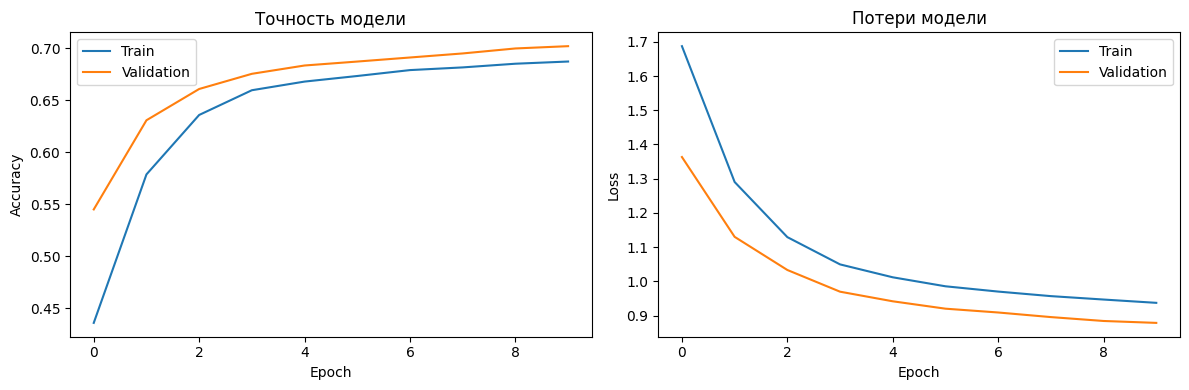

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
              precision    recall  f1-score   support

    Bathroom       0.53      0.41      0.47       510
     Bedroom       0.82      0.92      0.87      1311
  DiningRoom       0.61      0.29      0.39       582
   GuestRoom       0.36      0.25      0.29       572
     Kitchen       0.82      0.92      0.87      2596
  LivingRoom       0.49      0.61      0.54      1773
 LoungeChair       0.78      0.75      0.77      2017
   OtherRoom       0.75      0.06      0.10       217
 OutsideDoor       0.71      0.07      0.13        70
    WorkArea       0.67      0.83      0.74       352

    accuracy                           0.70     10000
   macro avg       0.66      0.51      0.52     10000
weighted avg       0.69      0.70      0.68     10000



In [5]:
# Ячейка 5 - Оценка модели
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# График обучения
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Точность модели')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Потери модели')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Оценка на тесте
y_pred = model.predict(X_test[:10000])
y_pred_classes = y_pred.argmax(axis=1)
y_true = y_test[:10000]

print(classification_report(y_true, y_pred_classes, target_names=le.classes_))

In [6]:
# Ячейка 6 - Сохранение модели
model.save('../models/lstm_model.keras')
print("Модель сохранена!")

FileNotFoundError: [Errno 2] No such file or directory: '../models/lstm_model.keras'

In [7]:
# Ячейка 6 - Сохранение модели
import os
os.makedirs('../models', exist_ok=True)
model.save('../models/lstm_model.keras')
print("Модель сохранена!")

Модель сохранена!
